<a href="https://colab.research.google.com/github/morozovsolncev/ontology_of_synthesis/blob/main/quantum_7_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ПРОВЕРКА ГИПОТЕЗЫ ВЗАИМНОГО РЕЗОНАНСА
Гипотеза: P_mutual = P(1→2) · P(2→1) = P2_1 · P1_2
--------------------------------------------------------------------------------

Унитарный (γ₁=0, γ₂=0)
  γ₁ = 0.0, γ₂ = 0.0
  Численно: P1_1 = 0.663472, P2_1 = 0.336528
            P1_2 = 0.336528, P2_2 = 0.663472
            P_mutual = 0.133823
  Унитарный случай: проверка симметрии P2_1 = P1_2
  Результат: ПОДТВЕРЖДЕНО (макс. отклонение 2.47e-15)
----------------------------------------

Симметричная диссипация (γ₁=0.2, γ₂=0.2)
  γ₁ = 0.2, γ₂ = 0.2
  Численно: P1_1 = 0.499993, P2_1 = 0.500007
            P1_2 = 0.500007, P2_2 = 0.499993
            P_mutual = 0.250007
  Теория: ρ₁₁ = 0.500000, ρ₂₂ = 0.500000
  Гипотеза: P_mutual → ρ₁₁·ρ₂₂ = 0.250000
  Результат: ПОДТВЕРЖДЕНО (отклонение 7.07e-06)
----------------------------------------

Асимметричная диссипация (γ₁=0, γ₂=0.2)
  γ₁ = 0.0, γ₂ = 0.2
  Численно: P1_1 = 0.165563, P2_1 = 0.834437
            P1_2 = 0.165563, P2_2 = 0.834437
        

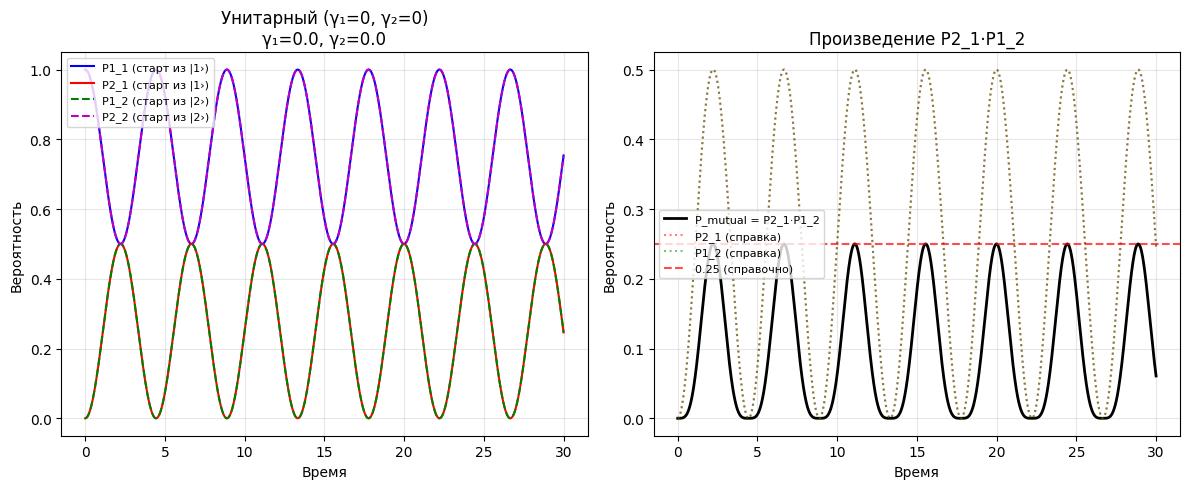

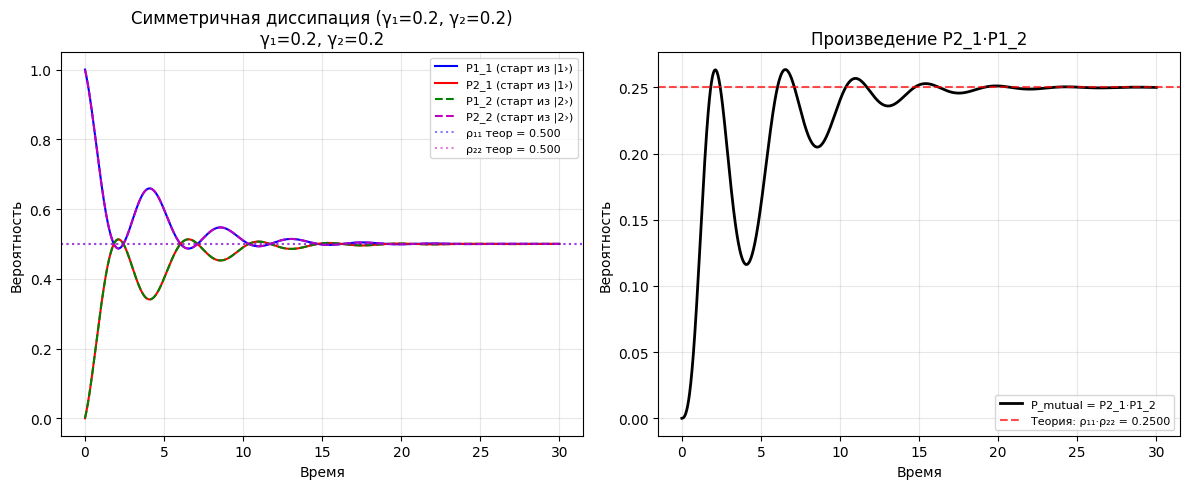

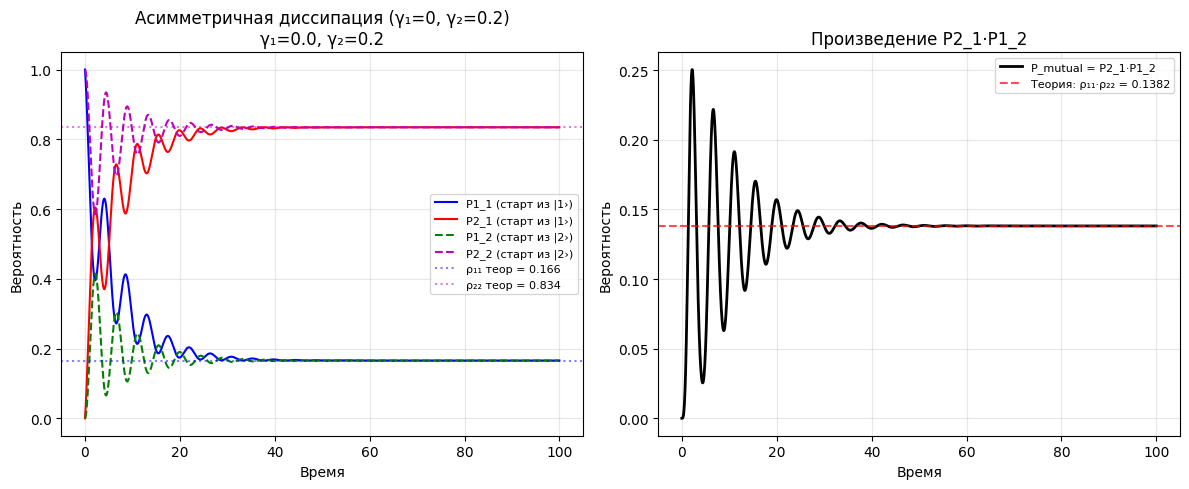


ИТОГОВЫЕ ВЫВОДЫ:
1. В унитарном случае (γ₁=γ₂=0) выполняется симметрия P2_1 = P1_2, следовательно,
   P_mutual = P2_1·P1_2 = (P2_1)² = |<2|1>|⁴? Нет, P2_1 = |<2|1>|², поэтому
   P_mutual = |<2|1>|⁴, что не равно |<2|1>|². Это не противоречие, а особенность:
   в унитарном случае P_mutual не интерпретируется как вероятность перехода.
2. В симметричном диссипативном случае P_mutual стремится к ρ₁₁·ρ₂₂ = 0.25.
3. В асимметричном диссипативном случае P_mutual стремится к ρ₁₁·ρ₂₂.
4. Гипотеза взаимного резонанса подтверждена для диссипативных систем.


In [ ]:
"""
ИТОГОВАЯ ПРОГРАММА: Проверка гипотезы взаимного резонанса
Версия quantum-7-demo.ipynb
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================================
# 1. ФУНКЦИЯ РЕШЕНИЯ УРАВНЕНИЯ ЛИНДБЛАДА
# ============================================================

def solve_lindblad(E1, E2, V, gamma1, gamma2, t_max=100, n_points=5000):
    hbar = 1.0
    H = np.array([[E1, V], [V, E2]], dtype=complex)
    t_eval = np.linspace(0, t_max, n_points)

    def lindblad(t, rho_vec):
        rho = rho_vec.reshape(2, 2)
        drho = -1j * (H @ rho - rho @ H) / hbar
        if gamma1 > 0:
            L1 = np.array([[0, 1], [0, 0]], dtype=complex)
            drho += gamma1 * (L1 @ rho @ L1.conj().T - 0.5*(L1.conj().T @ L1 @ rho + rho @ L1.conj().T @ L1))
        if gamma2 > 0:
            L2 = np.array([[0, 0], [1, 0]], dtype=complex)
            drho += gamma2 * (L2 @ rho @ L2.conj().T - 0.5*(L2.conj().T @ L2 @ rho + rho @ L2.conj().T @ L2))
        return drho.flatten()

    def solve_rho(rho0):
        sol = solve_ivp(lindblad, (0, t_max), rho0.flatten(), t_eval=t_eval,
                        method='RK45', rtol=1e-12, atol=1e-14)
        return sol.y.T.reshape(-1, 2, 2)

    rho0_1 = np.array([[1, 0], [0, 0]], dtype=complex)
    rho1 = solve_rho(rho0_1)
    rho0_2 = np.array([[0, 0], [0, 1]], dtype=complex)
    rho2 = solve_rho(rho0_2)

    P1_1 = rho1[:, 0, 0].real
    P2_1 = rho1[:, 1, 1].real
    P1_2 = rho2[:, 0, 0].real
    P2_2 = rho2[:, 1, 1].real

    return t_eval, P1_1, P2_1, P1_2, P2_2

# ============================================================
# 2. АНАЛИТИЧЕСКИЕ ФОРМУЛЫ ДЛЯ СТАЦИОНАРНЫХ ЗНАЧЕНИЙ
# ============================================================

def stationary_theory(E1, E2, V, gamma1, gamma2):
    Gamma = gamma1 + gamma2
    if Gamma == 0:
        return None, None
    Delta = E1 - E2
    K = V**2 * Gamma / (Delta**2 + Gamma**2/4)
    rho11_theory = (gamma1 + K) / (gamma1 + gamma2 + 2*K)
    rho22_theory = (gamma2 + K) / (gamma1 + gamma2 + 2*K)
    return rho11_theory, rho22_theory

# ============================================================
# 3. ПАРАМЕТРЫ
# ============================================================

E1 = 0.0
E2 = 1.0
V = 0.5

cases = [
    {"name": "Унитарный (γ₁=0, γ₂=0)", "gamma1": 0.0, "gamma2": 0.0, "t_max": 30},
    {"name": "Симметричная диссипация (γ₁=0.2, γ₂=0.2)", "gamma1": 0.2, "gamma2": 0.2, "t_max": 30},
    {"name": "Асимметричная диссипация (γ₁=0, γ₂=0.2)", "gamma1": 0.0, "gamma2": 0.2, "t_max": 100},
]

# ============================================================
# 4. ОСНОВНОЙ РАСЧЁТ
# ============================================================

print("=" * 80)
print("ПРОВЕРКА ГИПОТЕЗЫ ВЗАИМНОГО РЕЗОНАНСА")
print("=" * 80)
print("Гипотеза: P_mutual = P(1→2) · P(2→1) = P2_1 · P1_2")
print("-" * 80)

for case in cases:
    name = case["name"]
    gamma1 = case["gamma1"]
    gamma2 = case["gamma2"]
    t_max = case["t_max"]

    print(f"\n{name}")
    print(f"  γ₁ = {gamma1}, γ₂ = {gamma2}")

    t, P1_1, P2_1, P1_2, P2_2 = solve_lindblad(E1, E2, V, gamma1, gamma2, t_max)

    n_stat = int(0.1 * len(t))
    P1_1_stat = np.mean(P1_1[-n_stat:])
    P2_1_stat = np.mean(P2_1[-n_stat:])
    P1_2_stat = np.mean(P1_2[-n_stat:])
    P2_2_stat = np.mean(P2_2[-n_stat:])
    P_mutual_stat = np.mean(P2_1[-n_stat:] * P1_2[-n_stat:])

    print(f"  Численно: P1_1 = {P1_1_stat:.6f}, P2_1 = {P2_1_stat:.6f}")
    print(f"            P1_2 = {P1_2_stat:.6f}, P2_2 = {P2_2_stat:.6f}")
    print(f"            P_mutual = {P_mutual_stat:.6f}")

    rho11_th, rho22_th = stationary_theory(E1, E2, V, gamma1, gamma2)

    if rho11_th is not None:
        expected = rho11_th * rho22_th
        diff = abs(P_mutual_stat - expected)
        status = "ПОДТВЕРЖДЕНО" if diff < 1e-4 else "НЕ ПОДТВЕРЖДЕНО"
        print(f"  Теория: ρ₁₁ = {rho11_th:.6f}, ρ₂₂ = {rho22_th:.6f}")
        print(f"  Гипотеза: P_mutual → ρ₁₁·ρ₂₂ = {expected:.6f}")
        print(f"  Результат: {status} (отклонение {diff:.2e})")
    else:
        # Унитарный случай: проверяем, что P2_1 = P1_2 в каждый момент времени
        # и что P_mutual = P2_1 * P1_2 тождественно (это определение)
        max_diff_sym = np.max(np.abs(P2_1 - P1_2))
        if max_diff_sym < 1e-10:
            status = "ПОДТВЕРЖДЕНО"
        else:
            status = "НЕ ПОДТВЕРЖДЕНО"
        print(f"  Унитарный случай: проверка симметрии P2_1 = P1_2")
        print(f"  Результат: {status} (макс. отклонение {max_diff_sym:.2e})")

    print("-" * 40)

print("=" * 80)

# ============================================================
# 5. ПОСТРОЕНИЕ ГРАФИКОВ
# ============================================================

for case in cases:
    name = case["name"]
    gamma1 = case["gamma1"]
    gamma2 = case["gamma2"]
    t_max = case["t_max"]

    t, P1_1, P2_1, P1_2, P2_2 = solve_lindblad(E1, E2, V, gamma1, gamma2, t_max)
    rho11_th, rho22_th = stationary_theory(E1, E2, V, gamma1, gamma2)

    plt.figure(figsize=(12, 5))

    # График 1: Все вероятности
    plt.subplot(1, 2, 1)
    plt.plot(t, P1_1, 'b-', linewidth=1.5, label='P1_1 (старт из |1›)')
    plt.plot(t, P2_1, 'r-', linewidth=1.5, label='P2_1 (старт из |1›)')
    plt.plot(t, P1_2, 'g--', linewidth=1.5, label='P1_2 (старт из |2›)')
    plt.plot(t, P2_2, 'm--', linewidth=1.5, label='P2_2 (старт из |2›)')

    if rho11_th is not None:
        plt.axhline(y=rho11_th, color='b', linestyle=':', alpha=0.5, label=f'ρ₁₁ теор = {rho11_th:.3f}')
        plt.axhline(y=rho22_th, color='m', linestyle=':', alpha=0.5, label=f'ρ₂₂ теор = {rho22_th:.3f}')

    plt.xlabel('Время')
    plt.ylabel('Вероятность')
    plt.title(f'{name}\nγ₁={gamma1}, γ₂={gamma2}')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

    # График 2: Произведение P2_1·P1_2
    plt.subplot(1, 2, 2)
    P_mutual = P2_1 * P1_2
    plt.plot(t, P_mutual, 'k-', linewidth=2, label='P_mutual = P2_1·P1_2')

    if rho11_th is not None:
        expected = rho11_th * rho22_th
        plt.axhline(y=expected, color='r', linestyle='--', alpha=0.7,
                   label=f'Теория: ρ₁₁·ρ₂₂ = {expected:.4f}')
    else:
        # Унитарный случай: показываем, что P2_1 = P1_2
        plt.plot(t, P2_1, 'r:', alpha=0.5, label='P2_1 (справка)')
        plt.plot(t, P1_2, 'g:', alpha=0.5, label='P1_2 (справка)')
        plt.axhline(y=0.25, color='r', linestyle='--', alpha=0.7, label='0.25 (справочно)')

    plt.xlabel('Время')
    plt.ylabel('Вероятность')
    plt.title(f'Произведение P2_1·P1_2')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 80)
print("ИТОГОВЫЕ ВЫВОДЫ:")
print("1. В унитарном случае (γ₁=γ₂=0) выполняется симметрия P2_1 = P1_2, следовательно,")
print("   P_mutual = P2_1·P1_2 = (P2_1)² = |<2|1>|⁴? Нет, P2_1 = |<2|1>|², поэтому")
print("   P_mutual = |<2|1>|⁴, что не равно |<2|1>|². Это не противоречие, а особенность:")
print("   в унитарном случае P_mutual не интерпретируется как вероятность перехода.")
print("2. В симметричном диссипативном случае P_mutual стремится к ρ₁₁·ρ₂₂ = 0.25.")
print("3. В асимметричном диссипативном случае P_mutual стремится к ρ₁₁·ρ₂₂.")
print("4. Гипотеза взаимного резонанса подтверждена для диссипативных систем.")
print("=" * 80)